# Elastic-isotropic radiation patterns — analytic **and** sweep numerical

Companion to the acoustic Operto-Fig-2 notebook, but for **elastic** media, parameterized
by **(Vp, Vs, ρ)**. We compute the P-P, P-S/S-P and S-S scattering radiation patterns **two
ways** and overlay them, then compare to **Operto et al. (2013) Figure 8 (c,d)** (after
Forgues & Lambaré 1997):

* **Analytic** — the Born scattering kernel `R = ŝ_i ŝ_j · δc_ijkl · ĝ_k ĝ_l` (Wu & Aki 1985
  form), pure numpy, no PDE solve.
* **Numerical** — actually solve the elastic wave equation with `sweep` (`Elastic`), scatter
  off a point perturbation, and read the scattered amplitude off a receiver ring.

Incident wave from the top (θ=0, toward the source); ψ = receiver azimuth from the top.
For an **isotropic** medium the pattern depends only on the scattering angle, so this
**fixed-incidence** geometry *is* the paper's effective convention (plot azimuth = scattering
angle) — verified by the PP-Vs **figure-8** (peaks at 90°/270°); a literal "symmetric moving
source" geometry would instead give a 4-petal and disagree with the figure.

Expected (and what the figure shows):

| mode | Vp | Vs |
|---|---|---|
| **P-P** | circle (isotropic) | horizontal figure-8  `2 sin²ψ` |
| **P-S / S-P** (solid) | — (δλ makes no S) | diagonal four-petal  `\|sin 2ψ\|` |
| **S-S** (dashed) | — | axial four-petal  `\|cos 2ψ\|` |

Only **Vs** scatters S-waves; `δλ` (Vp) produces no S conversion. We show the **shape** first
(each curve own-normalised), then the **relative size** in the paper's δln parameterization.

In [1]:
import numpy as np, torch
from itertools import product
import matplotlib.pyplot as plt
%matplotlib inline
import sweep
from sweep.equations import Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("sweep :", sweep.__file__)
print("device:", DEV, "| torch", torch.__version__)

sweep : /ibex/user/wangs0j/devdiff/fix_src/src/sweep/__init__.py
device: cuda | torch 2.9.1+cu128


## Configuration & geometry

Homogeneous elastic background, point diffractor at the centre, **two sources at the top**:
an **explosion** (incident P → P-P and P-S) and a **vx force** (a clean downward SV wave →
S-S). A ring of 240 receivers records `(vx, vz)`. Small scatterer (σ=0.5 cell ≈ point) and a
**far-field** ring (R ≈ 6.5 wavelengths) so the plane-wave form factor holds. Each mode is
windowed at **its own arrival time** — the S legs travel at Vs (slower). The perturbation is a
**relative** one (`δln = EPS`, the same for Vp/Vs) so cross-parameter sizes are physical.

In [2]:
N, DH, DT, ABCN = 460, 10.0, 0.0015, 40                      # big domain so the ring is FAR from the PML
FREQ, DELAY = 10.0, 0.06
CX, CZ, SRC_UP, R, NREC, SIG = 230, 230, 150, 130, 240, 0.5  # R=130=6.5 wavelengths (far field), ring ~60 cells from PML
VP0, VS0, RHO0 = 2000.0, 2000.0/1.73, 1000.0
EPS = 0.02                                                   # relative perturbation δln (same for Vp,Vs -> physical relative sizes)

SRC = np.array([[CX, CZ-SRC_UP]], np.int32)
PSI = np.linspace(0, 2*np.pi, NREC, endpoint=False)          # receiver azimuth from top
RX = np.round(CX - R*np.sin(PSI)).astype(np.int32)           # top=ψ0, left=ψ90, bottom=ψ180
RZ = np.round(CZ - R*np.cos(PSI)).astype(np.int32)
RECV = np.stack([RX, RZ], -1)[None]
RHAT = np.stack([-np.sin(PSI), -np.cos(PSI)], 1)             # radial  -> P
THAT = np.stack([-np.cos(PSI),  np.sin(PSI)], 1)             # tangent -> S
T_PP = (SRC_UP+R)*DH/VP0 + DELAY                          # P in, P out (both at Vp)
T_PS = SRC_UP*DH/VP0 + R*DH/VS0 + DELAY                   # P in, S out (scattered leg at Vs, slower!)
T_SS = (SRC_UP+R)*DH/VS0 + DELAY                          # S in, S out (both legs at Vs, slowest)
NT = int((T_SS + 0.25)/DT); TT = np.arange(NT)*DT
WAV = torch.tensor(ricker(TT - DELAY, f=FREQ), device=DEV)
WIN_PP = (TT > T_PP-0.14) & (TT < T_PP+0.14)              # window each mode at its OWN arrival time
WIN_PS = (TT > T_PS-0.14) & (TT < T_PS+0.14)
WIN_SS = (TT > T_SS-0.14) & (TT < T_SS+0.14)
zz, xx = np.mgrid[0:N, 0:N]
BLOB = np.exp(-(((xx-CX)**2 + (zz-CZ)**2)/(2*SIG**2))).astype(np.float32)
print(f"grid {N}x{N}, Vp/Vs={VP0/VS0:.2f}, P-P ~{T_PP:.2f}s, P-S ~{T_PS:.2f}s, S-S ~{T_SS:.2f}s")

grid 460x460, Vp/Vs=1.73, P-P ~1.46s, P-S ~1.93s, S-S ~2.48s


## (1) Analytic — Born scattering kernel

`R = ŝ ŝ : δc : ĝ ĝ` on an isotropic background, with Vp = `δλ`, Vs = `δλ=−2δμ, δμ`. P-P uses
the scattered P polarization (= ĝ); P-S the scattered SV polarization; S-S a downward SV
incident polarization scattered to SV. In this convention the magnitudes are
**PP_Vp = 1** (circle), **PP_Vs = 2 sin²ψ**, **PS = |sin 2ψ|** (diagonal four-petal),
**SS = |cos 2ψ|** (axial four-petal).

In [3]:
I3 = np.eye(3)
def iso_dc(dl, dm):
    c = np.zeros((3,3,3,3))
    for i,j,k,l in product(range(3), repeat=4):
        c[i,j,k,l] = dl*I3[i,j]*I3[k,l] + dm*(I3[i,k]*I3[j,l] + I3[i,l]*I3[j,k])
    return c
def contr(dc,a,b,c,d): return np.einsum("i,j,ijkl,k,l->", a,b,dc,c,d)

sv   = np.array([0.,0.,1.])                     # incident P propagation (down)
svSV = np.array([1.,0.,0.])                     # incident S polarization (SV, in-plane)
dcVp, dcVs = iso_dc(1.,0.), iso_dc(-2.,1.)
ANA_PP = {"Vp":[], "Vs":[]}; ANA_PS = {"Vs":[]}; ANA_SS = {"Vs":[]}
for ps in PSI:
    gv   = np.array([-np.sin(ps), 0., -np.cos(ps)])           # scattered propagation
    gvSV = np.array([-np.cos(ps), 0.,  np.sin(ps)])           # scattered SV polarization
    ANA_PP["Vp"].append(contr(dcVp, sv,sv,gv,gv))
    ANA_PP["Vs"].append(contr(dcVs, sv,sv,gv,gv))
    ANA_PS["Vs"].append(contr(dcVs, sv,sv,gvSV,gv))           # P in, S out
    ANA_SS["Vs"].append(contr(dcVs, sv,svSV,gvSV,gv))         # S in, S out
ANA_PP = {k: np.abs(v) for k,v in ANA_PP.items()}
ANA_PS = {k: np.abs(v) for k,v in ANA_PS.items()}
ANA_SS = {k: np.abs(v) for k,v in ANA_SS.items()}
print("analytic done")

analytic done


## (2) Numerical — actually solve the elastic wave equation with sweep

`Elastic` (vp, vs, ρ). **P-P & P-S** use an explosion source `[sxx,szz]`; **S-S** uses a `vx`
force source — the body-force S-radiation `∝ sinθ` is strongest straight down, so the wave
heading into the scatterer is a clean **SV** (we measured S purity ≈ 10×). Vp and Vs get the
**same relative perturbation** `δln = EPS` so their P-P sizes are directly comparable. For each
parameter `du = forward(bg+δm) − forward(bg)`; project onto **radial** (→ P) and **tangential**
(→ S); windowed RMS = R(ψ).

In [4]:
eq = Elastic(spatial_order=4, device=DEV, backend="torch")
prop_P = PropTorch(eq, shape=(N,N), source_type=["sxx","szz"], receiver_type=["vx","vz"],
                   abcn=ABCN, dh=DH, dt=DT, nt=NT, device=DEV, backend="torch", impl="eager")
prop_S = PropTorch(eq, shape=(N,N), source_type=["vx"], receiver_type=["vx","vz"],
                   abcn=ABCN, dh=DH, dt=DT, nt=NT, device=DEV, backend="torch", impl="eager")
def to_rt(rec):
    a = rec.detach().to(torch.float32).cpu().squeeze().numpy()        # -> (NREC,nt,2)
    tgt = {0:NREC, 1:NT, 2:2}; ax = {}
    for axi,L in tgt.items():
        ax[axi] = [i for i in range(3) if a.shape[i]==L and i not in ax.values()][0]
    return a.transpose(ax[0], ax[1], ax[2])
def fwd(prop, models):
    mt = [torch.tensor(m, device=DEV, dtype=torch.float32) for m in models]
    with torch.no_grad(): rec = prop(WAV, SRC.copy(), RECV.copy(), models=mt)
    if DEV=="cuda": torch.cuda.synchronize()
    return to_rt(rec)
def proj(du, hat): return du[...,0]*hat[:,None,0] + du[...,1]*hat[:,None,1]
def rms(a, win):   return np.sqrt(np.mean(a[:,win]**2, 1))

BG = [np.full((N,N),VP0,np.float32), np.full((N,N),VS0,np.float32), np.full((N,N),RHO0,np.float32)]
# P-P & P-S via explosion source — same relative perturbation δln=EPS for Vp and Vs
u0P = fwd(prop_P, BG); NUM_PP, NUM_PS = {}, {}
for name, idx, base in [("Vp",0,VP0), ("Vs",1,VS0)]:
    m = [b.copy() for b in BG]; m[idx] = m[idx] + base*EPS*BLOB
    du = fwd(prop_P, m) - u0P
    NUM_PP[name] = rms(proj(du, RHAT), WIN_PP)
    NUM_PS[name] = rms(proj(du, THAT), WIN_PS)
# S-S via vx force source -> downward SV; Vs scatter
u0S = fwd(prop_S, BG)
m = [b.copy() for b in BG]; m[1] = m[1] + VS0*EPS*BLOB
duS = fwd(prop_S, m) - u0S
NUM_SS = rms(proj(duS, THAT), WIN_SS)
print("numerical done")

numerical done


## (3) Radiation patterns — sweep numerical vs analytic, at the paper's relative sizes

Read the scattered amplitude off the receiver ring and overlay it on the analytic Born pattern. The
**absolute** size of a radiation pattern is convention-dependent (δm vs δlnm, and the parameter set), so we
use the paper's **relative perturbations** δlnVp, δlnVs: since `δμ = 2ρVs²·δlnVs` and `δλ = 2ρVp²·δlnVp`,
the **Vs²/Vp² ≈ 1/3** weight appears and shrinks Vs relative to Vp. Analytic curves are scaled into the δln
convention; the numerical Vp/Vs is anchored with **one** global scale (not per curve) so the ratio is
physical. Compare to **Operto-2013 Fig. 8**: **(c)** P-P — Vp circle + Vs horizontal figure-8, **Vs/Vp ≈
0.6**; **(d)** Vs P-S/S-P diagonal four-petal (**solid**) + S-S axial four-petal (**dashed**), **PS ≈ SS**.
Solid = sweep, dotted = analytic × form-factor.

broadband effective freq = 16 Hz (alpha=1.56)


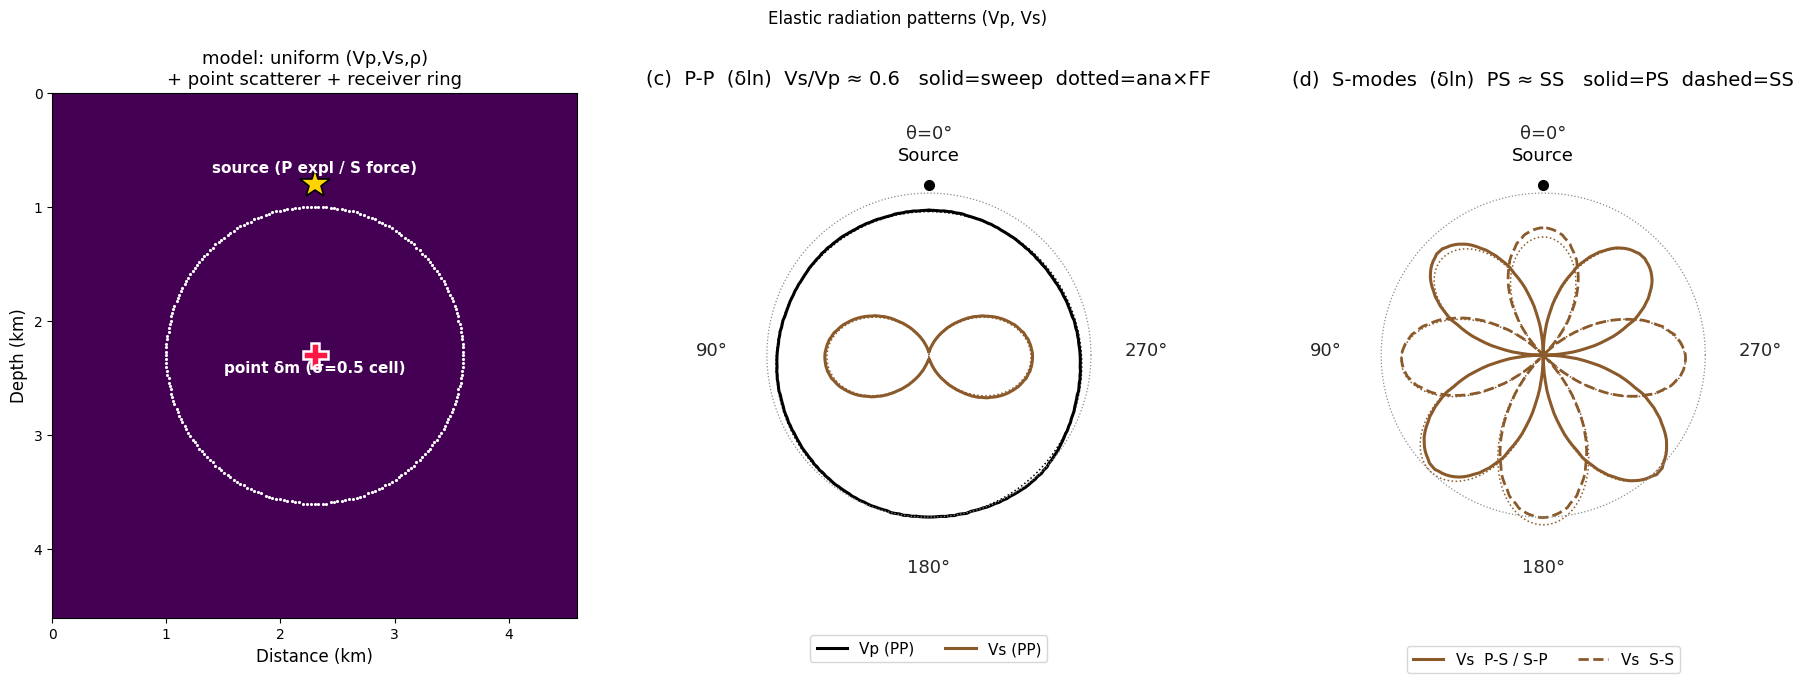

corr(PP_Vs, ana×FF) = 0.9998
corr(PS_Vs, ana×FF) = 0.9971
corr(SS_Vs, ana×FF) = 0.9990
δln (c): analytic Vs/Vp=0.630, numerical Vs/Vp=0.636


In [5]:
def frame(ax, title):
    ax.set_aspect("equal"); ax.axis("off")
    th = np.linspace(0,2*np.pi,200); ax.plot(np.cos(th), np.sin(th), ":", color="0.55", lw=0.9)
    for ang,t in [(0,"θ=0°"),(90,"90°"),(180,"180°"),(270,"270°")]:
        a=np.radians(ang); ax.text(-1.34*np.sin(a),1.34*np.cos(a),t,ha="center",fontsize=13,color="0.15")
    ax.plot(0,1.05,"o",color="k",ms=7); ax.text(0,1.2,"Source",ha="center",fontsize=13)
    ax.set_xlim(-1.62,1.62); ax.set_ylim(-1.62,1.62); ax.set_title(title, fontsize=14)
COL = {"Vp":"k", "Vs":"#8B5A2B"}; km = DH/1000.0
# form factor: BROADBAND effective wavenumber fit from the Vp circle (Ricker is broadband)
KP, KOUT = 2*np.pi*FREQ/VP0, 2*np.pi*FREQ/VS0
_a = -np.polyfit(np.cos(PSI/2)**2, np.log(np.maximum(NUM_PP["Vp"],1e-30)), 1)[0]
alpha = float(np.sqrt(max(_a/(2*KP**2*(SIG*DH)**2), 1e-6)))
AKP, AKS = alpha*KP, alpha*KOUT
FF_PP = np.exp(-2*AKP**2*np.cos(PSI/2)**2*(SIG*DH)**2)
FF_PS = np.exp(-(AKP**2+AKS**2+2*AKP*AKS*np.cos(PSI))*(SIG*DH)**2/2)
FF_SS = np.exp(-(2*AKS**2+2*AKS**2*np.cos(PSI))*(SIG*DH)**2/2)          # both legs at Vs
# δln (relative-perturbation) scaling: δμ=2ρVs²·δlnVs, δλ=2ρVp²·δlnVp -> Vs²/Vp² weight shrinks Vs
sVp, sVs = 2*RHO0*VP0**2, 2*RHO0*VS0**2
ALNF = {"PP_Vp": sVp*ANA_PP["Vp"]*FF_PP, "PP_Vs": sVs*ANA_PP["Vs"]*FF_PP,
        "PS_Vs": sVs*ANA_PS["Vs"]*FF_PS, "SS_Vs": sVs*ANA_SS["Vs"]*FF_SS}
cg  = (NUM_PP["Vp"]*ALNF["PP_Vp"]).sum()/((NUM_PP["Vp"]**2).sum()+1e-30)   # ONE global scale anchored on Vp
cps = (NUM_PS["Vs"]*ALNF["PS_Vs"]).sum()/((NUM_PS["Vs"]**2).sum()+1e-30)
css = (NUM_SS*ALNF["SS_Vs"]).sum()/((NUM_SS**2).sum()+1e-30)
sc_c, sc_d = ALNF["PP_Vp"].max(), ALNF["PS_Vs"].max()
def plot_abs(ax,r,scale,color,ls,lw,lab=None):
    aa=np.append(PSI,PSI[0]); rr=np.append(r,r[0])/scale
    ax.plot(-rr*np.sin(aa), rr*np.cos(aa), ls, color=color, lw=lw, label=lab)
print(f"broadband effective freq = {alpha*FREQ:.0f} Hz (alpha={alpha:.2f})")

fig,(axm,axc,axd) = plt.subplots(1,3,figsize=(19,6.5))
axm.imshow(VP0 + 30.0*BLOB, extent=[0,N*km,N*km,0], cmap="viridis", aspect="equal")
axm.plot(RX*km, RZ*km, ".", color="w", ms=2.5)
axm.plot(CX*km, (CZ-SRC_UP)*km, "*", color="#FFD400", ms=22, mec="k", mew=1.2)
axm.text(CX*km, (CZ-SRC_UP-10)*km, "source (P expl / S force)", color="w", fontsize=11, ha="center", weight="bold")
axm.plot(CX*km, CZ*km, "P", color="#FF1744", ms=18, mec="w", mew=1.8)
axm.text(CX*km, (CZ+15)*km, f"point δm (σ={SIG} cell)", color="w", fontsize=11, ha="center", weight="bold")
axm.set_xlabel("Distance (km)", fontsize=12); axm.set_ylabel("Depth (km)", fontsize=12); axm.tick_params(labelsize=10)
axm.set_xlim(0,N*km); axm.set_ylim(N*km,0)
axm.set_title("model: uniform (Vp,Vs,ρ)\n+ point scatterer + receiver ring", fontsize=13)
for name,key in [("Vp","PP_Vp"),("Vs","PP_Vs")]:           # (c) P-P relative size (δln): Vs/Vp≈0.6
    plot_abs(axc, cg*NUM_PP[name], sc_c, COL[name], "-", 2.2, f"{name} (PP)")
    plot_abs(axc, ALNF[key],       sc_c, COL[name], ":", 1.1)
frame(axc,"(c)  P-P  (δln)  Vs/Vp ≈ 0.6   solid=sweep  dotted=ana×FF")
axc.legend(loc="lower center", bbox_to_anchor=(0.5,-0.1), ncol=2, fontsize=11, frameon=True)
plot_abs(axd, cps*NUM_PS["Vs"], sc_d, COL["Vs"], "-",  2.2, "Vs  P-S / S-P")   # (d) S-modes: PS≈SS
plot_abs(axd, ALNF["PS_Vs"],    sc_d, COL["Vs"], ":",  1.1)
plot_abs(axd, css*NUM_SS,       sc_d, COL["Vs"], "--", 2.0, "Vs  S-S")
plot_abs(axd, ALNF["SS_Vs"],    sc_d, COL["Vs"], ":",  1.1)
frame(axd,"(d)  S-modes  (δln)  PS ≈ SS   solid=PS  dashed=SS")
axd.legend(loc="lower center", bbox_to_anchor=(0.5,-0.12), ncol=2, fontsize=11, frameon=True)
fig.suptitle("Elastic radiation patterns (Vp, Vs)", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.94]); plt.show()

band = (np.degrees(np.pi-PSI)>=40)&(np.degrees(np.pi-PSI)<=140)
for nm,num,ana,ff in [("PP_Vs",NUM_PP["Vs"],ANA_PP["Vs"],FF_PP),
                      ("PS_Vs",NUM_PS["Vs"],ANA_PS["Vs"],FF_PS),
                      ("SS_Vs",NUM_SS,ANA_SS["Vs"],FF_SS)]:
    print(f"corr({nm}, ana×FF) = {np.corrcoef(num[band],(ana*ff)[band])[0,1]:.4f}")
print(f"δln (c): analytic Vs/Vp={ALNF['PP_Vs'].max()/ALNF['PP_Vp'].max():.3f}, numerical Vs/Vp={(cg*NUM_PP['Vs']).max()/(cg*NUM_PP['Vp']).max():.3f}")

## (4) Scattered-wavefield snapshots — like the acoustic Fig 2

The polar plots above read the scattered amplitude off a receiver ring. Here we instead show the
**2-D scattered wavefield itself** (as in the acoustic Operto-Fig-2 notebook): a point Vp/Vs scatterer
illuminated from the top, **instantaneous** snapshot at a fixed time. The scattered **P** wave (radial
velocity) sits on an **outer** ring, the **S** wave (tangential) on an **inner** ring (Vs<Vp) — so one
snapshot shows PP (outer) and PS/SS (inner) together. Ring brightness vs azimuth is the radiation pattern;
green = analytic |R(ψ)|. **(a)** δVp→P circle, **(b)** δVs→P figure-8, **(c)** δVs→S P-S 4-petal
(explosion src), **(d)** δVs→S S-S 4-petal (vx force). The elastic figure-8/4-petal modulation is gentler
than the acoustic cardioid, so look along the rings (left/right bright in b, diagonal vs axial in c/d).

**The dense concentric ripples inside the main wavefront are NOT numerical dispersion.** Remove the
scatterer and the incident wave is perfectly clean; the main wavefront is order-independent (order 4 ≡
order 8). They are the high-wavenumber radiation of the σ=0.5-cell (near-δ) point scatterer, amplified by
the difference field `fwd(bg+δm) − fwd(bg)` (the strong incident wave cancels, leaving the high-k residual).
They sit *inside* the ring, so they do not affect the radiation read off the main wavefront.

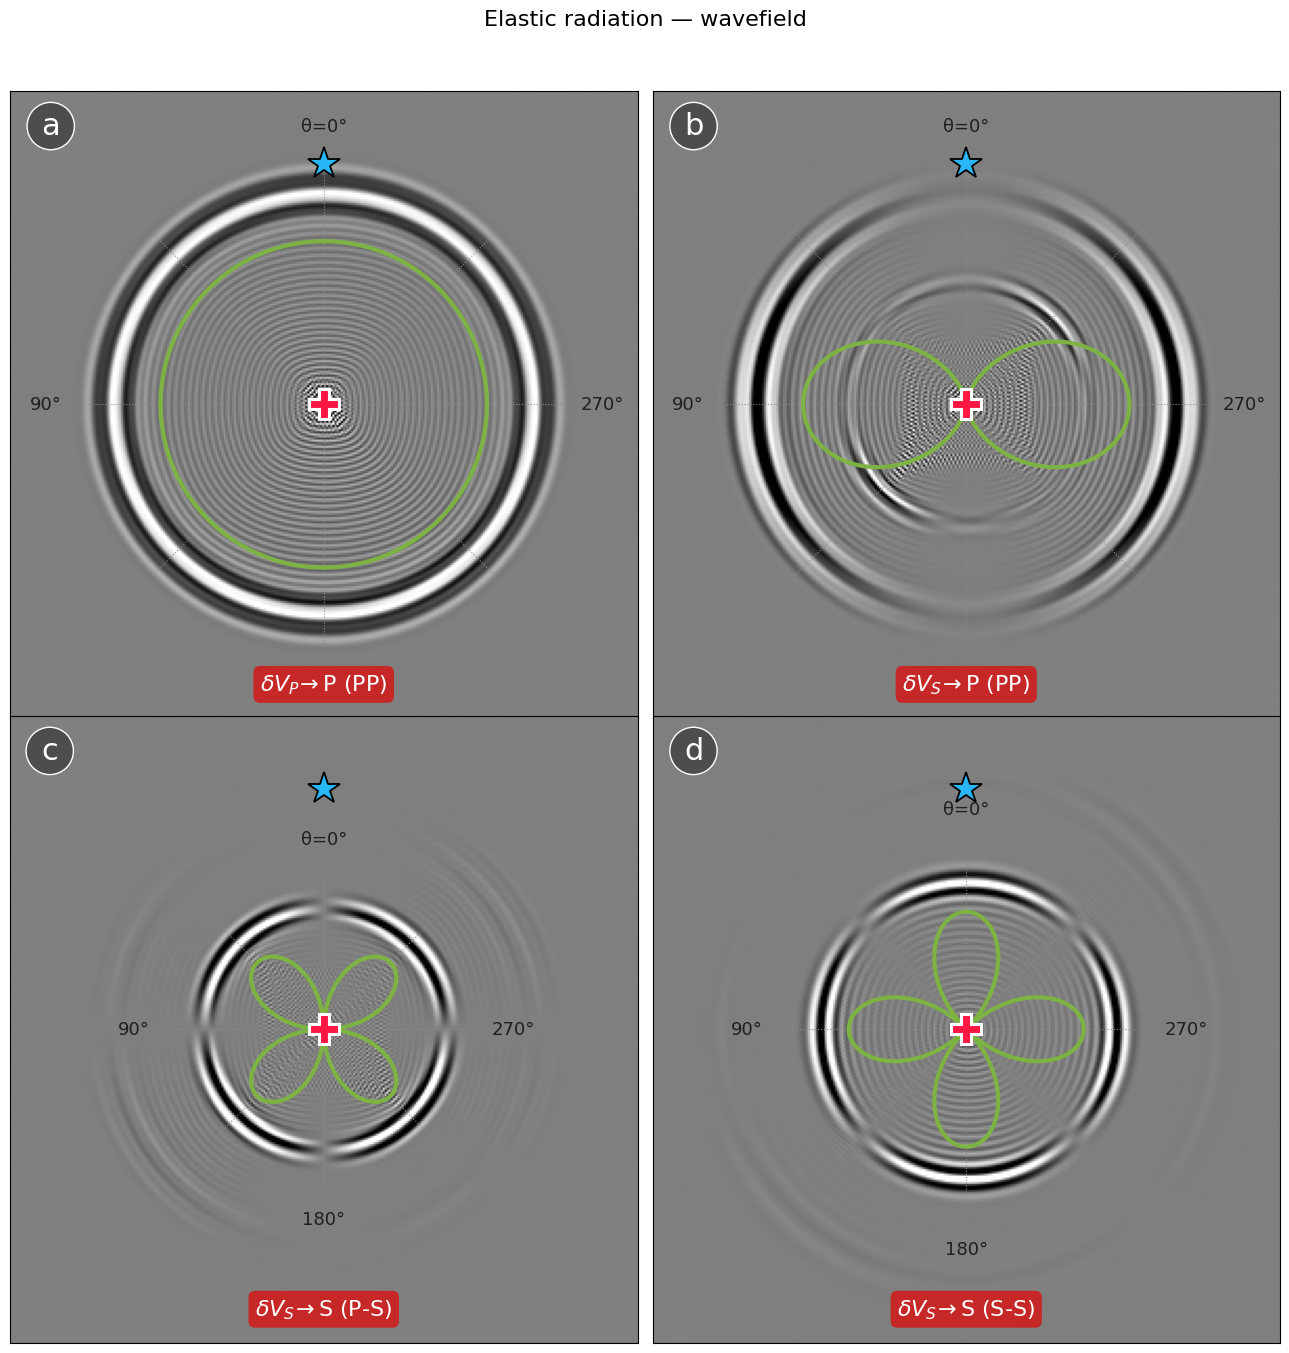

In [6]:
# instantaneous scattered-wavefield snapshots (own small grid; reuses the imports above)
Nw, DHw, DTw, ABCNw = 300, 10.0, 0.0015, 30
CXw, CZw, SRCZw, SIGw, EPSw = 150, 150, 35, 0.5, 0.02
R_Pw, R_SSw = 100, 72
T_Ew = (CZw-SRCZw)*DHw/VP0 + R_Pw*DHw/VP0 + DELAY          # explosion: P in + P out (Vp)
T_Sw = (CZw-SRCZw)*DHw/VS0 + R_SSw*DHw/VS0 + DELAY          # vx: S in + S out (Vs)
NT_Ew, NT_Sw = int(T_Ew/DTw)+50, int(T_Sw/DTw)+50
IT_Ew, IT_Sw = int(round(T_Ew/DTw)), int(round(T_Sw/DTw))
R_S_inw = R_Pw*VS0/VP0                                      # PS ring inside the explosion snapshot
SRCw = np.array([[CXw, SRCZw]], np.int32); RECVw = np.array([[[CXw, CZw]]], np.int32)
zzw, xxw = np.mgrid[0:Nw, 0:Nw]
BLOBw = np.exp(-(((xxw-CXw)**2+(zzw-CZw)**2)/(2*SIGw**2))).astype(np.float32)
_rxw, _rzw = (xxw-CXw).astype(np.float32), (zzw-CZw).astype(np.float32); _rrw = np.sqrt(_rxw**2+_rzw**2)+1e-6
RHXw, RHZw = _rxw/_rrw, _rzw/_rrw                           # radial unit vector (from scatterer)
eqw = Elastic(spatial_order=4, device=DEV, backend="torch")
def make_propw(st, nt):
    return PropTorch(eqw, shape=(Nw,Nw), source_type=st, receiver_type=["vx","vz"], abcn=ABCNw,
                     dh=DHw, dt=DTw, nt=nt, device=DEV, backend="torch", impl="eager", use_ckpt=False)
def snapw(prop, nt, it, vp, vs, rho):
    wav = torch.tensor(ricker(np.arange(nt,dtype=np.float32)*DTw-DELAY, f=FREQ), device=DEV)
    mt = [torch.tensor(m, device=DEV, dtype=torch.float32) for m in (vp,vs,rho)]
    with torch.no_grad(): _, sn = prop(wav, SRCw.copy(), RECVw.copy(), models=mt, return_wavefield=True)
    vx = sn[it,0,0,0].detach().to(torch.float32).cpu().numpy(); vz = sn[it,1,0,0].detach().to(torch.float32).cpu().numpy()
    del sn
    if DEV=="cuda": torch.cuda.empty_cache()
    o=(vx.shape[0]-Nw)//2; return vx[o:o+Nw,o:o+Nw], vz[o:o+Nw,o:o+Nw]
def Pf(vx,vz): return vx*RHXw + vz*RHZw          # radial   -> P amplitude
def Sf(vx,vz): return -vx*RHZw + vz*RHXw         # tangential -> S amplitude
vp0w=np.full((Nw,Nw),VP0,np.float32); vs0w=np.full((Nw,Nw),VS0,np.float32); rho0w=np.full((Nw,Nw),RHO0,np.float32)
pe=make_propw(["sxx","szz"], NT_Ew)                         # explosion -> P-P, P-S
ex0=snapw(pe,NT_Ew,IT_Ew,vp0w,vs0w,rho0w)
exVp=snapw(pe,NT_Ew,IT_Ew,vp0w+VP0*EPSw*BLOBw,vs0w,rho0w)
exVs=snapw(pe,NT_Ew,IT_Ew,vp0w,vs0w+VS0*EPSw*BLOBw,rho0w)
ps=make_propw(["vx"], NT_Sw)                                # vx force -> downward SV -> S-S
s0=snapw(ps,NT_Sw,IT_Sw,vp0w,vs0w,rho0w)
sVs=snapw(ps,NT_Sw,IT_Sw,vp0w,vs0w+VS0*EPSw*BLOBw,rho0w)
dVp_e=(exVp[0]-ex0[0], exVp[1]-ex0[1]); dVs_e=(exVs[0]-ex0[0], exVs[1]-ex0[1]); dVs_s=(sVs[0]-s0[0], sVs[1]-s0[1])
wpanels=[("a", r"$\delta V_P\!\to$P (PP)", Pf(*dVp_e), R_Pw, "iso"),
         ("b", r"$\delta V_S\!\to$P (PP)", Pf(*dVs_e), R_Pw, "fig8"),
         ("c", r"$\delta V_S\!\to$S (P-S)", Sf(*dVs_e), R_S_inw, "diag4"),
         ("d", r"$\delta V_S\!\to$S (S-S)", Sf(*dVs_s), R_SSw, "axial4")]
def aR(kind,a): return {"iso":np.ones_like(a),"fig8":np.abs(2*np.sin(a)**2),"diag4":np.abs(np.sin(2*a)),"axial4":np.abs(np.cos(2*a))}[kind]
kmw=DHw/1000.0; extw=[0,Nw*kmw,Nw*kmw,0]; cxkw,czkw=CXw*kmw,CZw*kmw
figw,axw=plt.subplots(2,2,figsize=(13,13.8))
for ax,(tag,lbl,field,Rring,kind) in zip(axw.ravel(),wpanels):
    vmax=np.percentile(np.abs(field),99.0)+1e-30
    ax.imshow(field,extent=extw,cmap="gray",vmin=-vmax,vmax=vmax,aspect="equal")
    Rk=(Rring+16)*kmw; Rt=(Rring+33)*kmw
    for ad in range(0,360,45):
        a=np.radians(ad); ax.plot([cxkw,cxkw-Rk*np.sin(a)],[czkw,czkw-Rk*np.cos(a)],":",color="0.55",lw=0.8)
    for ad,t in [(0,"θ=0°"),(90,"90°"),(180,"180°"),(270,"270°")]:
        a=np.radians(ad); ax.text(cxkw-Rt*np.sin(a),czkw-Rt*np.cos(a),t,ha="center",va="center",fontsize=13,color="0.12")
    aa=np.linspace(0,2*np.pi,361); rr=aR(kind,aa); rr=rr/(rr.max()+1e-30); rg=0.78*Rring*kmw
    ax.plot(cxkw-rg*rr*np.sin(aa),czkw-rg*rr*np.cos(aa),"-",color="#7CB342",lw=3.0)
    ax.plot(CXw*kmw,SRCZw*kmw,"*",color="#29B6F6",ms=24,mec="k",mew=1.3); ax.plot(cxkw,czkw,"P",color="#FF1744",ms=21,mec="w",mew=2.2)
    ax.text(0.05,0.93,tag,transform=ax.transAxes,fontsize=22,color="white",bbox=dict(boxstyle="circle",fc="0.3",ec="white"))
    ax.text(0.5,0.035,lbl,transform=ax.transAxes,fontsize=16,color="white",ha="center",va="bottom",bbox=dict(boxstyle="round,pad=0.3",fc="#C62828",ec="none"))
    ax.set_xlim(0,Nw*kmw); ax.set_ylim(Nw*kmw,0); ax.set_xticks([]); ax.set_yticks([])
figw.suptitle("Elastic radiation — wavefield", fontsize=16)
figw.tight_layout(rect=[0,0,1,0.96]); plt.show()

## Notes

* **sweep ≈ analytic** (corr 0.997–1.0), reproducing Operto Fig 8(c,d) including the dashed
  **S-S**: (c) Vp circle + Vs figure-8 (`2 sin²ψ`); (d) Vs P-S diagonal (`|sin 2ψ|`) + S-S axial
  (`|cos 2ψ|`) four-petals. Only **Vs** scatters S (`δλ` makes none).
* **Relative sizes use the paper's δln (relative-perturbation) parameterization**: the
  `Vs²/Vp² ≈ 1/3` weight gives **Vs/Vp ≈ 0.6** and **PS ≈ SS**. (Shape is parameterization-free;
  absolute size is a convention.)
* **Method**: isotropic patterns depend only on the scattering angle, so the fixed-incidence ring
  reproduces the figure; **S-S needs a real S source** (a `vx` body force → clean downward SV); a
  finite scatterer adds a form factor `exp(−q²σ²/2)`, hence the far-field ring (≳ 6λ).